In [1]:
import torch
from torch import nn # for neural networks
import matplotlib.pyplot as plt

#Check PyTorch Version
torch.__version__


'2.10.0+cpu'

In [2]:
# Data (preparing and loading)

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

In [4]:
# Splitting data into training, valitaion, test set

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10,7))

#plot
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", label="Predictions")

  #Show legend
  plt.legend(prop={"size": 14});



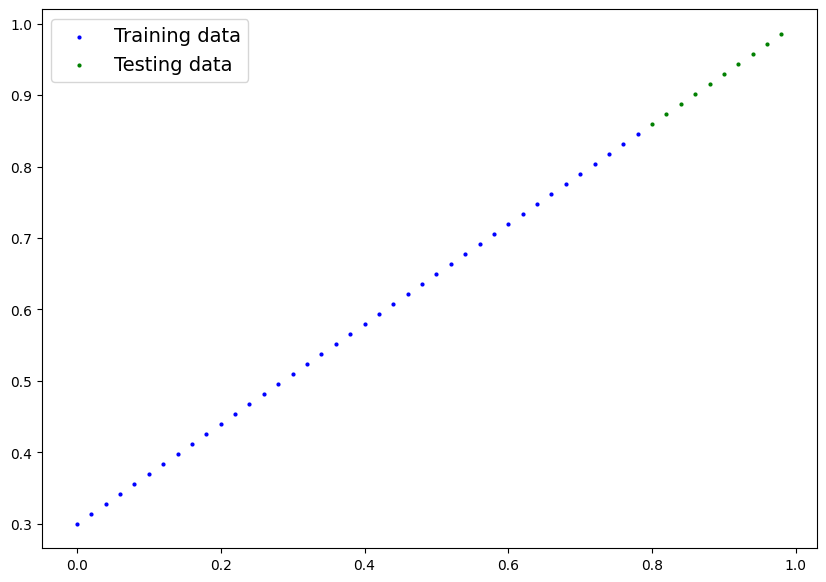

In [6]:
plot_predictions();

In [7]:
# Build Model
from torch import nn


class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                           requires_grad=True,
                                           dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  # Forward MEthod
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias


In [8]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [10]:
## Making Predictions using torch.inference_mode()

with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [11]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

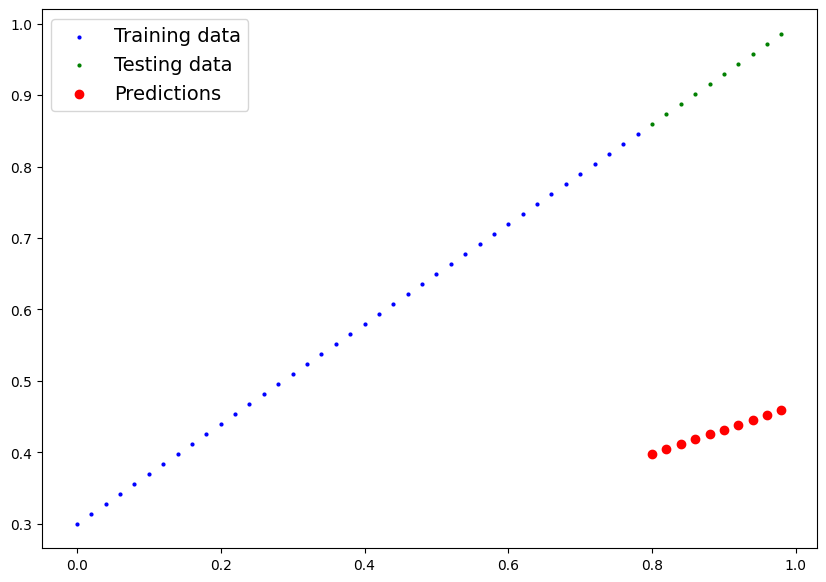

In [12]:
plot_predictions(predictions=y_preds)

In [13]:
# Train model, model will move from unknown parameters to known parameters.
# Loss Function Lower is better.
# Optimizer takes in loss and adjusts the model's parameters to improve the loss function (eg. weight & bias)
# a Training Loop and testing loop are needed

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [14]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [15]:
#Setup Loss Function

loss_fn = nn.L1Loss()


#Setup Optimizer

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)


In [49]:
# Building a training loop in Pytorch

# loop thru data
# Forward pass / propagation (data moves throw out the model)
# Calculate the loss
# Optimizer zero grad
# Loss backward - move backwaerds through the network to calcaluate the gradiensts of each of the paramater
#

epochs = 100

for epochs in range(epochs):

  # Set model to training mode
  model_0.train() # train mode set

  # 1. Forward pass
  y_preds = model_0(X_train)

  # Calculate loss
  loss = loss_fn(y_preds,y_train)
  print(f"loss:,{loss}")

  # Optimizier
  optimizer.zero_grad()

  # backprogation
  loss.backward()

  # Step Optimizer
  optimizer.step()


# Testing

model_0.eval()
print(model_0.state_dict())

loss:,0.017930403351783752
loss:,0.01758546568453312
loss:,0.017245199531316757
loss:,0.016896454617381096
loss:,0.01656000316143036
loss:,0.016210997477173805
loss:,0.01587124727666378
loss:,0.015525798313319683
loss:,0.015182236209511757
loss:,0.014840595424175262
loss:,0.01449323259294033
loss:,0.014155393466353416
loss:,0.013806397095322609
loss:,0.013468016870319843
loss:,0.013121193274855614
loss:,0.01277900766581297
loss:,0.012435992248356342
loss:,0.01208999752998352
loss:,0.011750795878469944
loss:,0.011401787400245667
loss:,0.011064787395298481
loss:,0.010716589167714119
loss:,0.010375778190791607
loss:,0.010031387209892273
loss:,0.009686763398349285
loss:,0.009346187114715576
loss:,0.008997755125164986
loss:,0.008660981431603432
loss:,0.008311985060572624
loss:,0.007972544990479946
loss:,0.007626785431057215
loss:,0.0072835334576666355
loss:,0.006941580679267645
loss:,0.006594526115804911
loss:,0.006256377790123224
loss:,0.005907376762479544
loss:,0.005569315515458584
loss:,

In [50]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

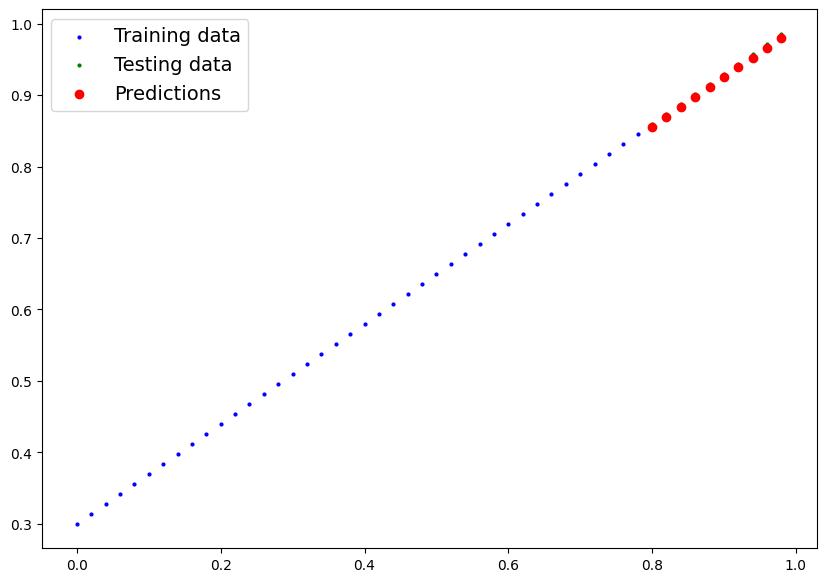

In [51]:
plot_predictions(predictions=y_preds_new);